In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')
print(df.head())
print(df.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [9]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 n

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
print("Cleaned!")
print(df.head())

Cleaned!
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

        Product ID         Category Sub-Category  \
0  FUR-BO-10001798        Furniture    Book

/tmp/ipykernel_6730/4198351988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=category_sales, palette='Set2')


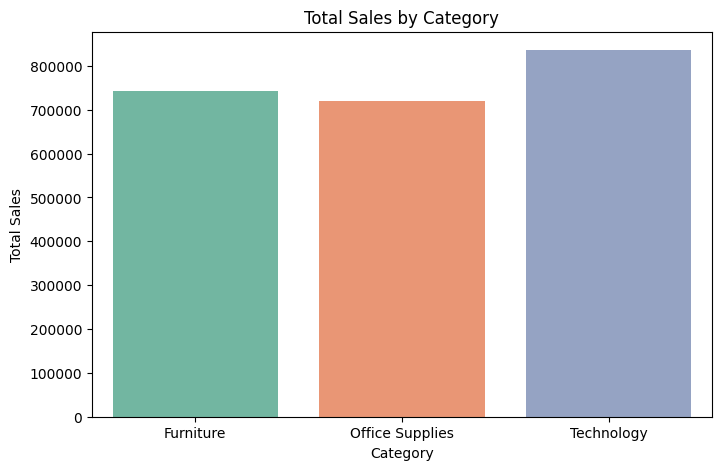

In [11]:
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category', y='Sales', data=category_sales, palette='Set2')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

/tmp/ipykernel_6730/538470089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=category_profit, palette='Set1')


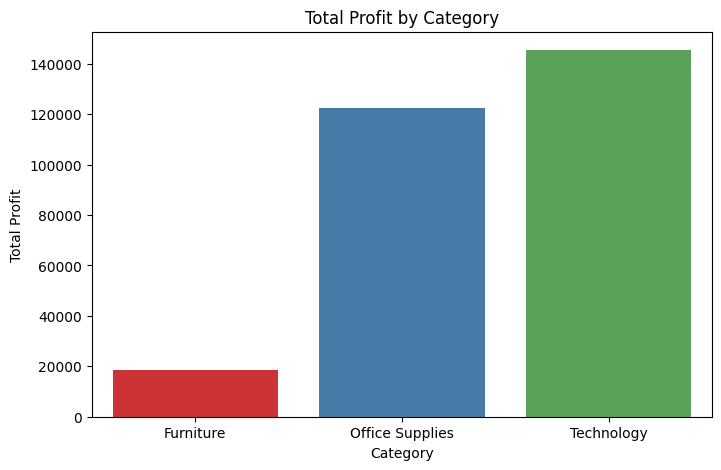

In [12]:
plt.figure(figsize=(8,5))
category_profit = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(x='Category', y='Profit', data=category_profit, palette='Set1')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

/tmp/ipykernel_6730/2172404704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=region_sales, palette='viridis')


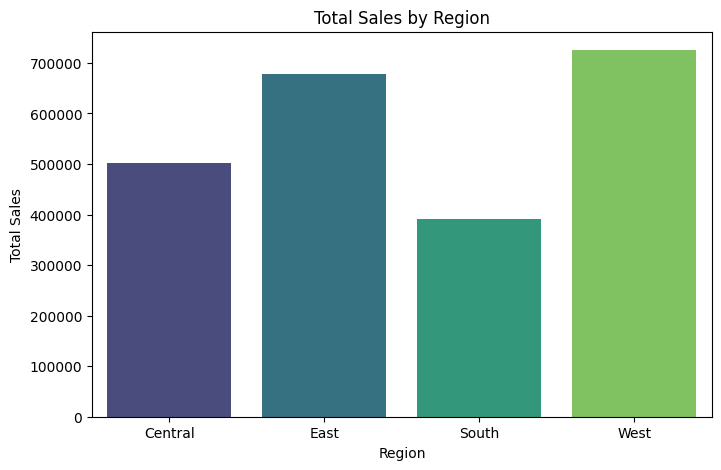

In [13]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(x='Region', y='Sales', data=region_sales, palette='viridis')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

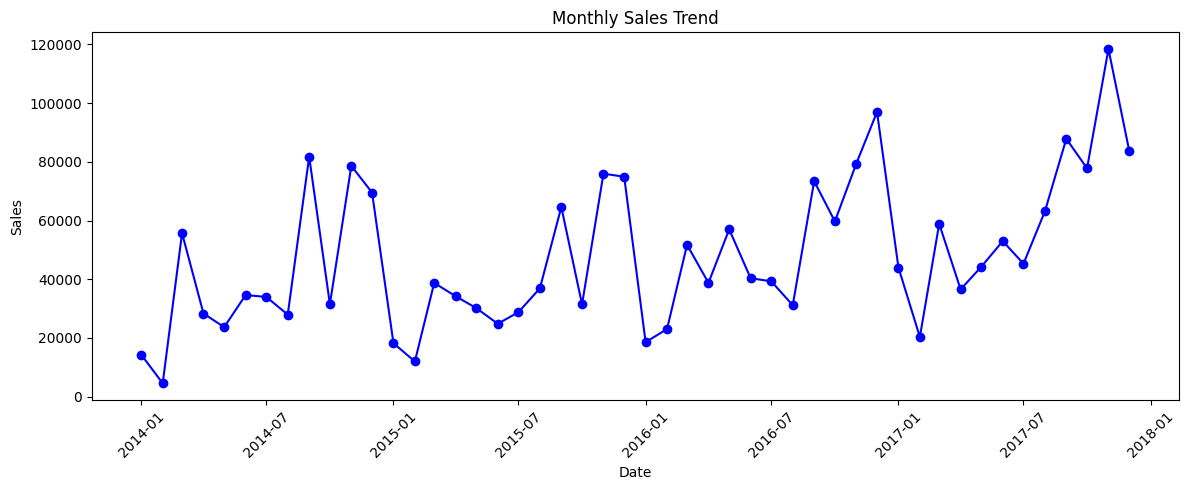

In [14]:
plt.figure(figsize=(12,5))
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(Day=1))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

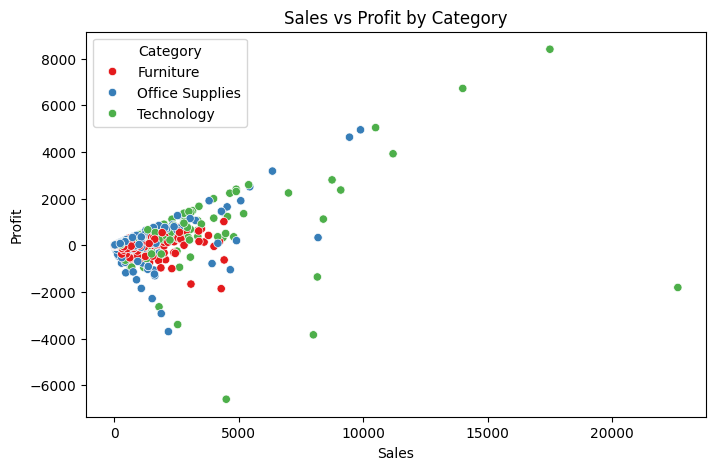

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df, palette='Set1')
plt.title('Sales vs Profit by Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

/tmp/ipykernel_6730/474585883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=top_products, palette='coolwarm')


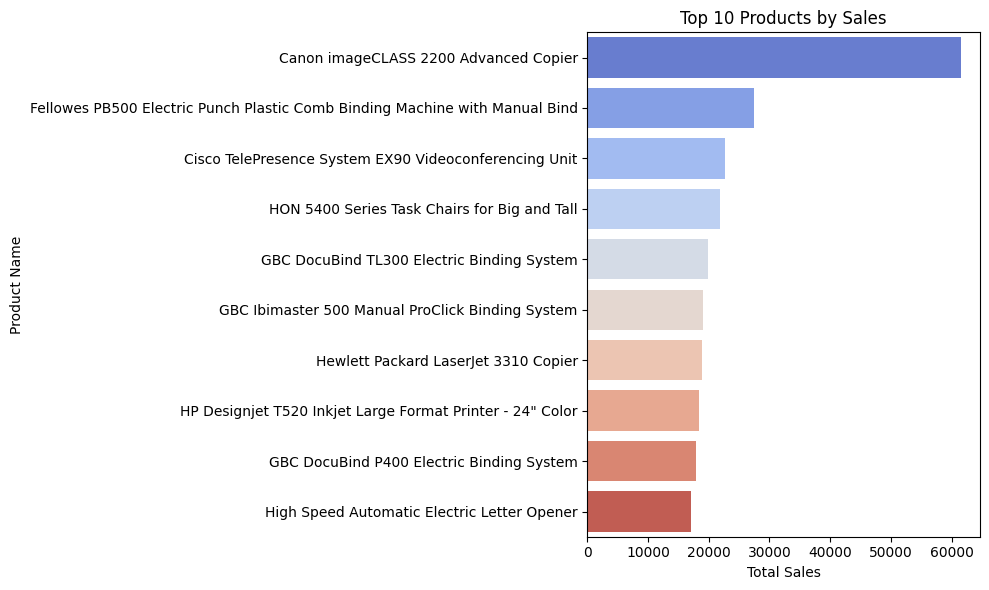

In [16]:
plt.figure(figsize=(10,6))
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(x='Sales', y='Product Name', data=top_products, palette='coolwarm')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6730/4152530728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ship Mode', data=df, palette='Set3')


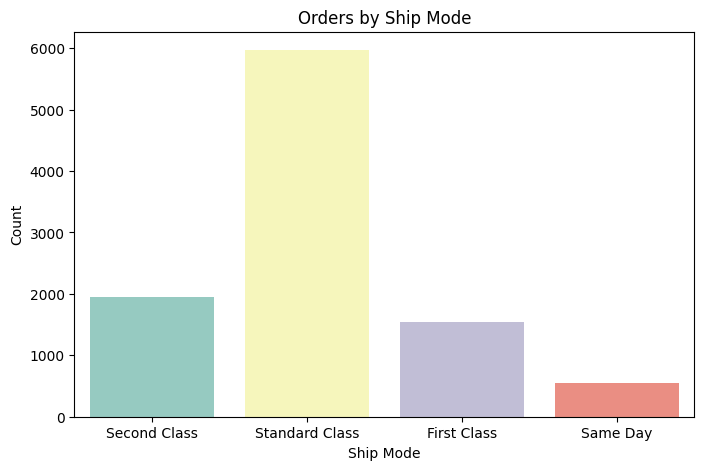

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Ship Mode', data=df, palette='Set3')
plt.title('Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Count')
plt.show()

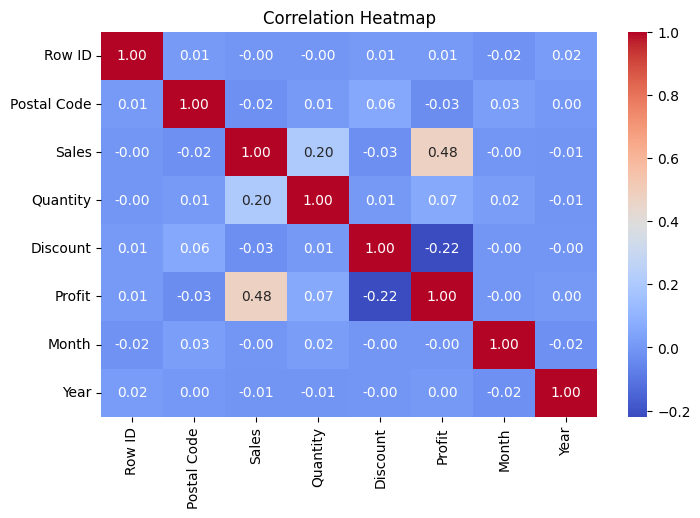

In [18]:
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_6730/460709741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Profit', data=region_profit, palette='Set2')


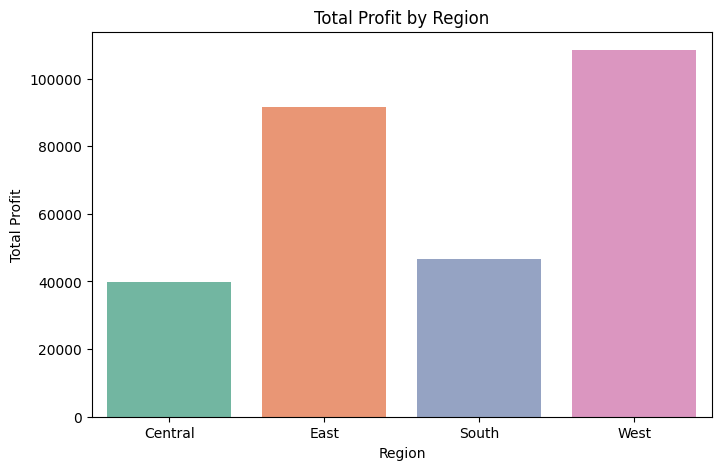

In [19]:
plt.figure(figsize=(8,5))
region_profit = df.groupby('Region')['Profit'].sum().reset_index()
sns.barplot(x='Region', y='Profit', data=region_profit, palette='Set2')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

In [20]:
print("=" * 50)
print("KEY INSIGHTS - RETAIL SALES ANALYSIS")
print("=" * 50)
print(f"Total Orders: {len(df)}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Order Value: ${df['Sales'].mean():,.2f}")
print(f"\nBest Category by Sales: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Best Category by Profit: {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"\nBest Region by Sales: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Best Region by Profit: {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"\nTop Product: {df.groupby('Product Name')['Sales'].sum().idxmax()}")
print("=" * 50)

KEY INSIGHTS - RETAIL SALES ANALYSIS
Total Orders: 9994
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Average Order Value: $229.86

Best Category by Sales: Technology
Best Category by Profit: Technology

Best Region by Sales: West
Best Region by Profit: West

Top Product: Canon imageCLASS 2200 Advanced Copier
